# Exercise 4b: Riemann Solvers for Burgers' Equation

## Learning Objectives

By completing this exercise, you will:
- Understand the conservative form of hyperbolic PDEs
- Implement a Riemann solver (Rusanov/Local Lax-Friedrichs)
- Compute interface fluxes on a staggered grid
- Compare diffusivity of Riemann solvers vs. the Lax method

---

## Introduction

We continue with Burgers' equation from [Exercise 3](https://github.com/AST-Course/AST5110/blob/main/notebooks/ex_3.ipynb):

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0   \tag{1}$$

**Setup:**
- Domain: $x \in [-1.4, 2.0]$
- Initial condition:
$$u(x,t=0) = A\left[\tanh\left(\frac{x+x_c}{W}\right)-\tanh\left(\frac{x-x_c}{W}\right)\right]   \tag{2}$$
- Parameters: $A = 0.02$, $x_c = 0.70$, $W = 0.1$
- Final time: $t_f = 100$

In this exercise, we implement a **Riemann solver** approach. See the [wiki: Riemann Solvers](https://github.com/AST-Course/AST5110/wiki/Riemann-solvers) for theoretical background.

**Implementation:** Fill in the function `evolv_Rie_uadv_burgers` in [`nm_lib/nm_ex/nm_lib_ex_4.py`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_4.py).

---

## The Riemann Solver Algorithm

### Step 1: Compute Left and Right States

Compute the left and right states at each interface:
- $u_L = u_i$ (left of interface $i+1/2$)
- $u_R = u_{i+1}$ (right of interface $i+1/2$)

### Step 2: Compute the Flux

Rewrite eq. (1) in **conservative form** to identify the flux $F(u)$.

From the left and right states, compute:
- $F_L = F(u_L)$
- $F_R = F(u_R)$

**Implementation:** Use `Rie_flux` in `nm_lib/nm_ex/nm_lib_ex_4.py`.

### Step 3: Compute the Wave Speed

The propagation speed is the derivative of the flux with respect to $u$:
$$v_a = \max\left( \left|\frac{\partial F}{\partial u}\right|_L, \left|\frac{\partial F}{\partial u}\right|_R \right)$$

This will be the derivatie of the flux with respect to variable $u$ in absolute values and select the largest between the left and right shells

**Implementation:** Use `Rie_va` in `nm_lib/nm_ex/nm_lib_ex_4.py`.

> See the [wiki: Riemann Solvers](https://github.com/AST-Course/AST5110/wiki/Riemann-solvers) for details on the propagation speed derivation.

### Step 4: Compute Interface Fluxes (Rusanov)

The **Rusanov flux** (Local Lax-Friedrichs) at interface $i+1/2$:

$$F^*_{i+1/2} = \frac{F_R + F_L}{2} - \frac{v_a}{2}(u_R - u_L)$$

> **Note:** $F^*_{i+1/2}$ is defined at **half-grid points** (staggered).

**Implementation:** Use `Rie_interface_flux` in `nm_lib/nm_ex/nm_lib_ex_4.py`.

### Step 5: Time Advance

Update the solution using flux differences:

$$u^{n+1}_i = u^n_i - \frac{\Delta t}{\Delta x}\left(F^*_{i+1/2} - F^*_{i-1/2}\right)$$

**Implementation:** Use `evolv_Rie_uadv_burgers` in `nm_lib/nm_ex/nm_lib_ex_4.py`.

**Question:** What is $\Delta t$ given the phase speed $v_a$? (CFL condition)

In [1]:
import torch 
import matplotlib.pyplot as plt
import importlib
import nm_lib.nm_ex.nm_lib_ex_4 as nm4
importlib.reload(nm4)
device = torch.device("cpu")
dtype = torch.float64
def lax_burgers_one_step_from_lib(x_t, u_t, cfl_cut=0.8):
    x_np = x_t.detach().cpu().numpy()
    u_np = u_t.detach().cpu().numpy()

    t_np, unnt_np = nm4.evolv_Lax_uadv_burgers(
        x_np, u_np, nt=1, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    dt = t_np[1] - t_np[0]
    u_new = torch.tensor(unnt_np[-1], dtype=u_t.dtype, device=u_t.device)
    return u_new, float(dt)


def rusanov_burgers_one_step_from_lib(x_t, u_t, cfl_cut=0.8):
    x_np = x_t.detach().cpu().numpy()
    u_np = u_t.detach().cpu().numpy()

    t_np, unnt_np = nm4.evolv_Rie_uadv_burgers(
        x_np, u_np, nt=1, cfl_cut=cfl_cut, bnd_type="wrap"
    )

    dt = t_np[1] - t_np[0]
    u_new = torch.tensor(unnt_np[-1], dtype=u_t.dtype, device=u_t.device)
    return u_new, float(dt)
print("Using device:", device)
#Problem 4b

# Parameter.

x0=-1.4
xf = 2
A = 0.02
W = 0.1
xc = 0.7
v = 0.1
N = 512 #In this problem does not specify N, I just assumed that N = 512, which works well.    
tf = 100.0    
CFL = 0.8 
#Intial
def burgers_initial(x, A=0.02, xc=0.7, W=0.1):
    return A * (torch.tanh((x + xc)/W) - torch.tanh((x - xc)/W))
"""
#Conservative Lax-Friedrichs and Rusanov
def F_burgers(u):
    return 0.5 * u * u  # F(u)=u^2/2

def evolv_Lax_uadv_burgers(u, dx, dt):
    N = u.numel()
    u_new = torch.zeros_like(u)
    lam = dt / (2.0 * dx)

    for j in range(N):
        jp = (j + 1) % N   # j+1 periodic
        jm = (j - 1) % N   # j-1 periodic

        u_new[j] = 0.5 * (u[jp] + u[jm]) - lam * (F_burgers(u[jp]) - F_burgers(u[jm]))

    return u_new

def rusanov_interface_flux(uL, uR):
    
    FL = 0.5 * uL * uL
    FR = 0.5 * uR * uR
    a  = torch.maximum(torch.abs(uL), torch.abs(uR))
    return 0.5 * (FL + FR) - 0.5 * a * (uR - uL)


def evolv_Rusanov_burgers(u, dx, dt):
    N = u.numel()
    u_new = torch.zeros_like(u)

    # F_half[j] means flux at interface (j+1/2) between j and j+1
    F_half = torch.zeros_like(u)

    #interface fluxes
    for j in range(N):
        jp = (j + 1) % N
        F_half[j] = rusanov_interface_flux(u[j], u[jp])

    # update by flux difference
    for j in range(N):
        jm = (j - 1) % N
        u_new[j] = u[j] - (dt / dx) * (F_half[j] - F_half[jm])

    return u_new
"""

def total_variation_periodic(u):
    # TV = sum |u_{i}-u_{i-1}| with periodic wrap
    N = u.numel()
    tv = 0.0
    for j in range(N):
        jm = (j - 1) % N
        tv += abs((u[j] - u[jm]).item())
    return tv

def to_np(u):
    return u.cpu().numpy()


Using device: cpu


---

## Part 2: Comparison with Lax Method

### Task 2.1: Compare Diffusivity

**Questions:**
1. Is the Riemann solver more or less diffusive than the Lax method?
2. Find the analytical solution and compare with both numerical methods
3. Where and when does each method perform better or worse?

---

## Background: Riemann Solver Variants

> **Note:** Different Riemann solvers use different approximations for $F^*$ and the wave speed $v_a$, but they all follow the same algorithmic steps:
> - **Rusanov (LLF):** Uses maximum wave speed (most diffusive)
> - **HLL:** Uses two wave speeds (less diffusive)
> - **HLLC:** Includes contact discontinuity (even less diffusive)
> - **Roe:** Uses linearized Jacobian (least diffusive, but can fail)

---

## Hints

<details>
<summary><b>Hint 1: Conservative form of Burgers' equation</b></summary>

The conservative form is:
$$\frac{\partial u}{\partial t} + \frac{\partial F}{\partial x} = 0$$

where the flux is $F(u) = \frac{u^2}{2}$.
</details>

<details>
<summary><b>Hint 2: Wave speed for Burgers' equation</b></summary>

Since $F(u) = u^2/2$, we have:
$$\frac{\partial F}{\partial u} = u$$

So $v_a = \max(|u_L|, |u_R|)$.
</details>

<details>
<summary><b>Hint 3: CFL condition with Riemann solver</b></summary>

The time step is limited by the maximum wave speed:
$$\Delta t = \text{CFL} \cdot \frac{\Delta x}{\max(v_a)}$$

with CFL $\leq 1$ for stability.
</details>


Compare Lax vs Rusanov (Burgers)
Lax:     t = 99.997782, steps = 736
Rusanov: t = 99.939974, steps = 719
Peak: initial=0.040000 | Lax=0.032669 | Rusanov=0.032180
TV:   initial=0.080000 | Lax=0.062060 | Rusanov=0.062028


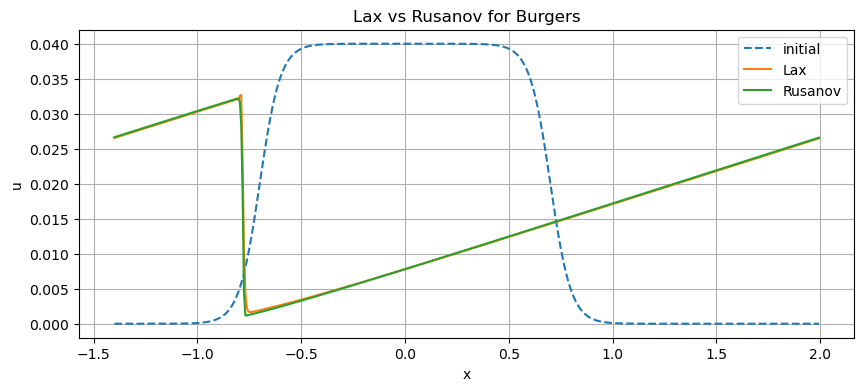

: 

In [ ]:


# Part 2 Compare Lax vs Rusanov for Burgers, same intial, and same CFL


# Use x0, xf, A, xc, W, tf, CFL, N

# periodic grid
dx = (xf - x0) / N
x  = x0 + dx * torch.arange(N, device=device, dtype=dtype)

u0 = burgers_initial(x, A=A, xc=xc, W=W)
# evolve Lax
u_lax = u0.clone()
t_lax = 0.0
steps_lax = 0

while t_lax < tf:
    u_new, dt = lax_burgers_one_step_from_lib(x, u_lax, cfl_cut=CFL)
    if t_lax + dt > tf:
        break
    u_lax = u_new
    t_lax += dt
    steps_lax += 1

# evolve Rusanov
u_rie = u0.clone()
t_rie = 0.0
steps_rie = 0

while t_rie < tf:
    u_new, dt = rusanov_burgers_one_step_from_lib(x, u_rie, cfl_cut=CFL)
    if t_rie + dt > tf:
        break
    u_rie = u_new
    t_rie += dt
    steps_rie += 1

print("\nCompare Lax vs Rusanov (Burgers)")
print(f"Lax:     t = {t_lax:.6f}, steps = {steps_lax}")
print(f"Rusanov: t = {t_rie:.6f}, steps = {steps_rie}")
print(f"Peak: initial={torch.max(u0).item():.6f} | Lax={torch.max(u_lax).item():.6f} | Rusanov={torch.max(u_rie).item():.6f}")
print(f"TV:   initial={total_variation_periodic(u0):.6f} | Lax={total_variation_periodic(u_lax):.6f} | Rusanov={total_variation_periodic(u_rie):.6f}")

plt.figure(figsize=(10,4))
plt.plot(to_np(x), to_np(u0), '--', label='initial')
plt.plot(to_np(x), to_np(u_lax), label='Lax')
plt.plot(to_np(x), to_np(u_rie), label='Rusanov')
plt.xlabel('x')
plt.ylabel('u')
plt.title('Lax vs Rusanov for Burgers')
plt.legend()
plt.grid(True)
plt.show()


# The Lax and Rusanov solutions are very similar in this test.
# Their peak values and total variation are almost identical,
# so no strong difference in numerical diffusion is observed here.